<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_052_permutation_feature_importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 52/365 — Permutation Feature Importance
## Which features does a trained model actually rely on?

Over the last few days, we explored tree ensembles such as Random Forest, XGBoost, LightGBM, and CatBoost.

Today we shift from **prediction** to **interpretability**.

**Permutation Feature Importance** asks a simple question:

> What happens to model performance if I destroy the information in one feature?

Steps:
1. Measure normal model performance.
2. Shuffle one feature.
3. Measure performance again.
4. If performance drops a lot, the model relied heavily on that feature.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score


## 1. Load a real dataset


In [2]:
data=load_breast_cancer(as_frame=True)
X=data.data
y=data.target

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42,stratify=y
)

print("Dataset shape:",X.shape)
print("Classes:",data.target_names)


Dataset shape: (569, 30)
Classes: ['malignant' 'benign']


## 2. Train a Random Forest


In [3]:
model=RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train,y_train)

baseline_accuracy=accuracy_score(
    y_test,
    model.predict(X_test)
)

print("Baseline Test Accuracy:",round(baseline_accuracy,3))


Baseline Test Accuracy: 0.958


## 3. Shuffle one feature

If a feature is useful, randomly shuffling it breaks its relationship with the target.

If accuracy drops, that suggests the model relied on that feature.


In [4]:
feature="worst radius"

X_shuffled=X_test.copy()
rng=np.random.default_rng(42)

X_shuffled[feature]=rng.permutation(
    X_shuffled[feature].values
)

shuffled_accuracy=accuracy_score(
    y_test,
    model.predict(X_shuffled)
)

print("Baseline Accuracy:",round(baseline_accuracy,3))
print("Accuracy after shuffling:",feature,"=",round(shuffled_accuracy,3))
print("Accuracy drop:",round(baseline_accuracy-shuffled_accuracy,3))


Baseline Accuracy: 0.958
Accuracy after shuffling: worst radius = 0.965
Accuracy drop: -0.007


## 4. Calculate Permutation Importance for every feature


In [5]:
result=permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
    scoring="accuracy"
)

importance=pd.DataFrame({
    "Feature":X.columns,
    "Mean Importance":result.importances_mean,
    "Std":result.importances_std
}).sort_values(
    "Mean Importance",
    ascending=False
)

display(importance.head(10).round(4))


,Feature,Mean Importance,Std
21,worst texture,0.0042,0.0034
22,worst perimeter,0.0017,0.0066
26,worst concavity,0.0010,0.0025
24,worst smoothness,0.0010,0.0025
7,mean concave points,0.0007,0.0044
27,worst concave points,0.0003,0.0068
5,mean compactness,0.0000,0.0000
6,mean concavity,0.0000,0.0000
8,mean symmetry,0.0000,0.0000
0,mean radius,0.0000,0.0000


## 5. Visualize the most important features


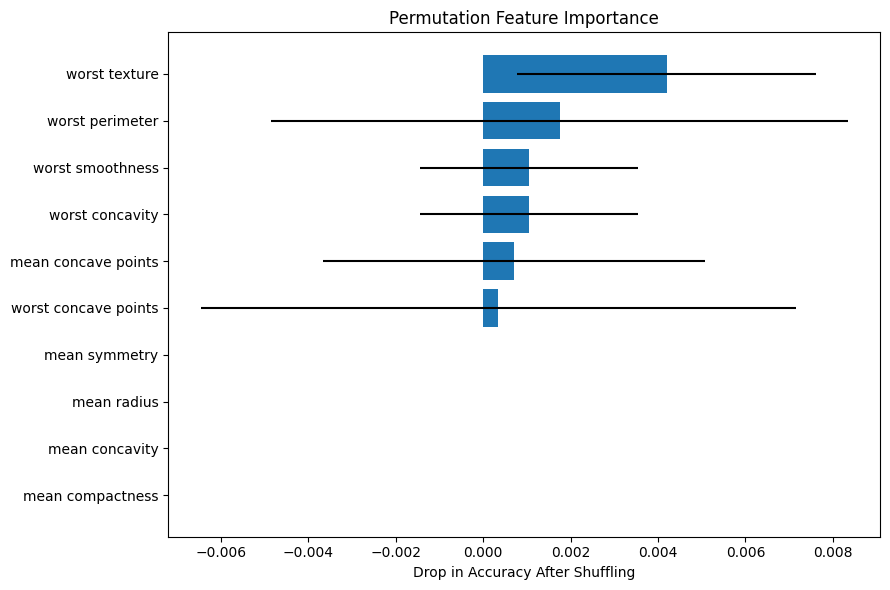

In [6]:
top10=importance.head(10).sort_values("Mean Importance")

plt.figure(figsize=(9,6))
plt.barh(
    top10["Feature"],
    top10["Mean Importance"],
    xerr=top10["Std"]
)
plt.xlabel("Drop in Accuracy After Shuffling")
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()


## 6. Compare with Random Forest's built-in importance

Random Forest also gives us:

`feature_importances_`

That is based on impurity reduction inside the trees.

Permutation importance asks a different question:

> What happens to predictive performance if this feature's information is broken?


In [7]:
tree_importance=pd.DataFrame({
    "Feature":X.columns,
    "Impurity Importance":model.feature_importances_
}).sort_values(
    "Impurity Importance",
    ascending=False
)

comparison=importance.merge(
    tree_importance,
    on="Feature"
)

display(
    comparison.sort_values(
        "Mean Importance",
        ascending=False
    ).head(10).round(4)
)


,Feature,Mean Importance,Std,Impurity Importance
0,worst texture,0.0042,0.0034,0.0167
1,worst perimeter,0.0017,0.0066,0.1457
2,worst concavity,0.0010,0.0025,0.0282
3,worst smoothness,0.0010,0.0025,0.0146
4,mean concave points,0.0007,0.0044,0.0983
5,worst concave points,0.0003,0.0068,0.1146
6,mean compactness,0.0000,0.0000,0.0172
7,mean concavity,0.0000,0.0000,0.0452
8,mean symmetry,0.0000,0.0000,0.0038
9,mean radius,0.0000,0.0000,0.0607


## 7. Important caveat: correlated features

If two features carry similar information, shuffling one may not hurt much because the model can still rely on the other.

So:

**Low permutation importance does not automatically mean a feature is irrelevant in the real world.**


## Enterprise intuition

Imagine a fraud model using:

- transaction amount
- device age
- merchant category
- location risk
- account age
- transaction velocity

Stakeholders ask:

**Which inputs is the model actually depending on?**

Permutation importance lets us test this experimentally.

If shuffling transaction amount changes almost nothing, but shuffling transaction velocity causes a large performance drop, the model is more dependent on transaction velocity.

This can help with:
- model review
- feature debugging
- monitoring
- feature selection
- stakeholder explanations

But it does **not** prove causality.


## What does this teach?

- Feature importance is about model reliance, not causality.
- Permutation importance measures performance degradation after shuffling one feature.
- Larger performance drops usually indicate greater model dependence.
- It is model-agnostic.
- Repeating the shuffle gives a more stable estimate.
- Correlated features can complicate interpretation.

> **A feature is important to a model when breaking its information meaningfully hurts model performance.**


## References

- https://scikit-learn.org/stable/modules/permutation_importance.html
- https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html
- https://link.springer.com/article/10.1023/A:1010933404324
- https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
